Akshat Keshri (iitp_aiml_2506515 )

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

In [70]:
!mv "german_credit_data.csv" Dataset/

mv: cannot stat 'german_credit_data.csv': No such file or directory


In [71]:
import pandas as pd
df = pd.read_csv("Dataset/german_credit_data.csv")
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,56,male,1,own,little,moderate,6745,22,car,good
1,69,female,2,free,moderate,moderate,10437,70,car,good
2,46,male,3,own,quite rich,little,9763,8,car,good
3,32,female,1,own,moderate,little,18964,70,radio/TV,bad
4,60,male,2,own,moderate,little,17650,14,domestic appliances,good


In [72]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   915 non-null    object
 5   Checking account  905 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,85
Checking account,95
Credit amount,0
Duration,0
Purpose,0
Risk,0


In [73]:
PLOTS_DIR = "../Visualization/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

def save_plot(filename):
    plt.savefig(os.path.join(PLOTS_DIR, filename), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

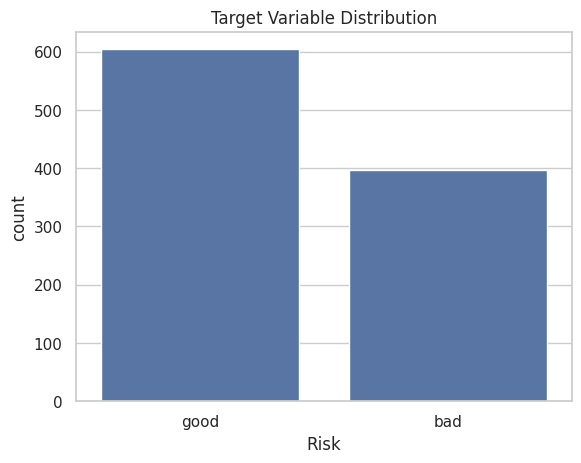

In [74]:
sns.countplot(x='Risk', data=df)
plt.title("Target Variable Distribution")

save_plot("target_distribution.png")

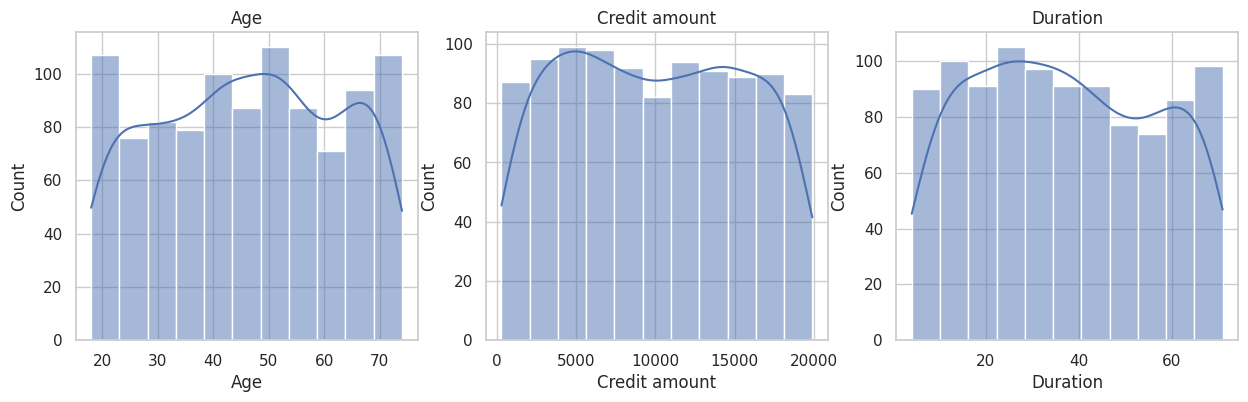

In [75]:
num_features = ['Age', 'Credit amount', 'Duration']

plt.figure(figsize=(15,4))
for i, col in enumerate(num_features, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

save_plot("numerical_histograms.png")

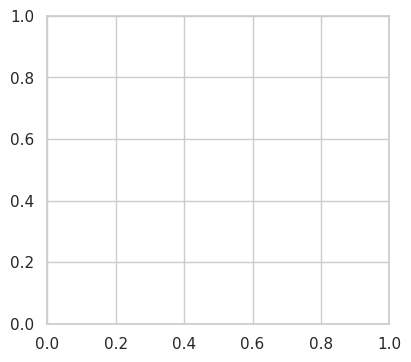

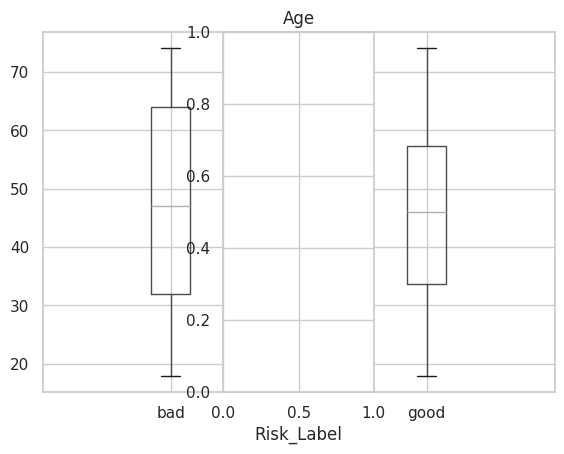

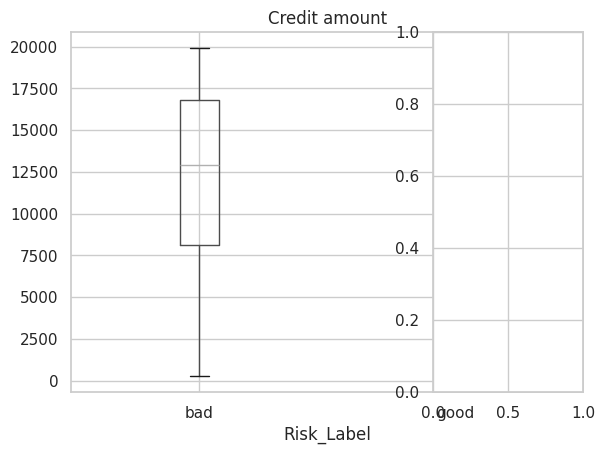

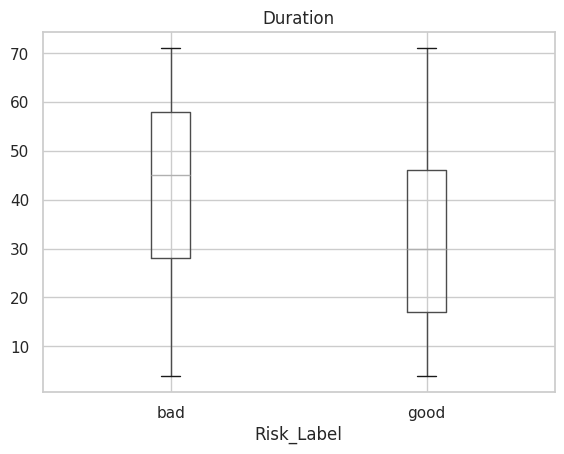

In [76]:
df['Risk_Label'] = df['Risk']

plt.figure(figsize=(15,4))
for i, col in enumerate(num_features, 1):
    plt.subplot(1, 3, i)
    df.boxplot(column=col, by='Risk_Label')
    plt.title(col)
    plt.suptitle("")

save_plot("boxplots_by_risk.png")
df.drop(columns=['Risk_Label'], inplace=True)

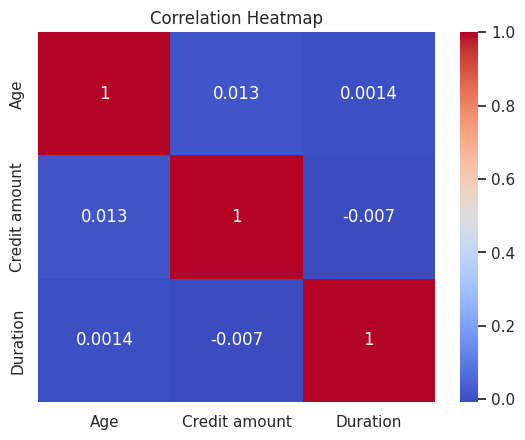

In [77]:
corr = df[num_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

save_plot("correlation_heatmap.png")

In [78]:
df['Saving accounts'].fillna(df['Saving accounts'].mode()[0], inplace=True)
df['Checking account'].fillna(df['Checking account'].mode()[0], inplace=True)
df['Risk'] = df['Risk'].map({'good': 0, 'bad': 1})

/tmp/ipython-input-3545174781.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Saving accounts'].fillna(df['Saving accounts'].mode()[0], inplace=True)
/tmp/ipython-input-3545174781.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(va

In [79]:
df['Credit_to_Duration_Ratio'] = df['Credit amount'] / df['Duration']
bins = [18, 25, 35, 50, 100]
labels = ['18-25', '26-35', '36-50', '50+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
high_risk = ['education', 'business', 'repairs']
df['High_Risk_Purpose'] = df['Purpose'].apply(lambda x: 1 if x in high_risk else 0)
account_map = {'little':1, 'moderate':2, 'rich':3, 'quite rich':4}

df['Saving_Score'] = df['Saving accounts'].map(account_map)
df['Checking_Score'] = df['Checking account'].map(account_map)

df['Account_Stability'] = df['Saving_Score'] + df['Checking_Score']
df.drop(columns=['Saving_Score','Checking_Score'], inplace=True)

In [80]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [81]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Risk', axis=1)
y = df_encoded['Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_df = X_train.copy()
train_df['Risk'] = y_train.values

test_df = X_test.copy()
test_df['Risk'] = y_test.values

In [82]:
train_df.to_csv("Dataset/train_data.csv", index=False)
test_df.to_csv("Dataset/test_data.csv", index=False)

In [83]:
df['Credit_to_Duration_Ratio'] = df['Credit amount'] / df['Duration']


age_bins = [18, 25, 35, 50, 100]
age_labels = ['18-25', '26-35', '36-50', '50+']

df['Age_Group'] = pd.cut(
    df['Age'],
    bins=age_bins,
    labels=age_labels
)


high_risk_purposes = ['education', 'business', 'repairs']

df['High_Risk_Purpose'] = df['Purpose'].apply(
    lambda x: 1 if x in high_risk_purposes else 0
)


account_mapping = {
    'little': 1,
    'moderate': 2,
    'rich': 3,
    'quite rich': 4
}

df['Saving_Score'] = df['Saving accounts'].map(account_mapping)
df['Checking_Score'] = df['Checking account'].map(account_mapping)

df['Account_Stability'] = df['Saving_Score'] + df['Checking_Score']

df.drop(columns=['Saving_Score', 'Checking_Score'], inplace=True)

In [84]:
df[
    [
        'Credit_to_Duration_Ratio',
        'Age_Group',
        'High_Risk_Purpose',
        'Account_Stability'
    ]
].head()

,Credit_to_Duration_Ratio,Age_Group,High_Risk_Purpose,Account_Stability
0,306.590909,50+,0,3
1,149.100000,50+,0,4
2,1220.375000,36-50,0,5
3,270.914286,26-35,0,3
4,1260.714286,50+,0,3
